<a href="https://colab.research.google.com/github/Gabrinetio/Data_Science/blob/main/Analise_churnV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Verificação rápida do Plotly Express
try:
    import plotly
    import plotly.express as px
    print("Plotly instalado com sucesso.")
    print("Versão do plotly:", plotly.__version__)
    # teste rápido de criação de figura (não mostra, apenas cria)
    import pandas as pd
    df_tmp = pd.DataFrame({"x": [1,2,3], "y": [1,4,9]})
    fig = px.line(df_tmp, x="x", y="y", title="Teste Plotly Express")
    print("Figura criada com sucesso (px.line)")
except Exception as e:
    import sys
    print("Falha ao importar/usar plotly.express:", e)
    print("Python:", sys.version)

Plotly instalado com sucesso.
Versão do plotly: 5.24.1
Figura criada com sucesso (px.line)


In [3]:
# Verificação rápida do Plotly Express
try:
    import plotly
    import plotly.express as px
    print("Plotly instalado com sucesso.")
    print("Versão do plotly:", plotly.__version__)
    # teste rápido de criação de figura (não mostra, apenas cria)
    import pandas as pd
    df_tmp = pd.DataFrame({"x": [1,2,3], "y": [1,4,9]})
    fig = px.line(df_tmp, x="x", y="y", title="Teste Plotly Express")
    print("Figura criada com sucesso (px.line)")
except Exception as e:
    import sys
    print("Falha ao importar/usar plotly.express:", e)
    print("Python:", sys.version)

Plotly instalado com sucesso.
Versão do plotly: 5.24.1
Figura criada com sucesso (px.line)


In [4]:
# Verificação do IProgress (ipywidgets)
from IPython.display import display
import ipywidgets as widgets
import time

progress = widgets.FloatProgress(value=0.0, min=0.0, max=1.0, description='Carregando:', bar_style='info')
display(progress)
for i in range(100):
    progress.value = (i + 1) / 100.0
    time.sleep(0.01)
progress.bar_style = 'success'
print('IProgress (ipywidgets) ok!')

FloatProgress(value=0.0, bar_style='info', description='Carregando:', max=1.0)

IProgress (ipywidgets) ok!


In [5]:
# Célula 1: Importações e Carga dos Dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregue o arquivo CSV que você baixou
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Visualizar as primeiras linhas e informações gerais
print("Amostra dos Dados:")
display(df.head())

print("\nInformações Gerais do DataFrame:")
df.info()


Amostra dos Dados:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informações Gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

In [6]:
# Célula 2: Tradução dos Dados para Português

print("Iniciando a tradução dos dados...")

# 1. Dicionário para traduzir os NOMES DAS COLUNAS
colunas_traducao = {
    'customerID': 'ID_Cliente',
    'gender': 'Gênero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Possui_Parceiro',
    'Dependents': 'Possui_Dependentes',
    'tenure': 'Tempo_de_Contrato_Meses',
    'PhoneService': 'Serviço_Telefônico',
    'MultipleLines': 'Múltiplas_Linhas',
    'InternetService': 'Serviço_de_Internet',
    'OnlineSecurity': 'Segurança_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Proteção_de_Aparelho',
    'TechSupport': 'Suporte_Técnico',
    'StreamingTV': 'Streaming_de_TV',
    'StreamingMovies': 'Streaming_de_Filmes',
    'Contract': 'Tipo_de_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Método_de_Pagamento',
    'MonthlyCharges': 'Cobrança_Mensal',
    'TotalCharges': 'Cobrança_Total',
    'Churn': 'Churn'
}

# 2. Traduzindo os VALORES DENTRO das colunas categóricas
# Gênero
df['gender'].replace({'Male': 'Masculino', 'Female': 'Feminino'}, inplace=True)

# Mapeamento simples de Sim/Não para várias colunas
colunas_sim_nao = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for coluna in colunas_sim_nao:
    df[coluna].replace({'Yes': 'Sim', 'No': 'Não'}, inplace=True)

# Mapeamentos específicos
df['MultipleLines'].replace({'No phone service': 'Sem serviço telefônico'}, inplace=True)
df['MultipleLines'].replace({'Yes': 'Sim', 'No': 'Não'}, inplace=True)

df['InternetService'].replace({'Fiber optic': 'Fibra Ótica', 'No': 'Não'}, inplace=True)

colunas_servico_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for coluna in colunas_servico_internet:
    df[coluna].replace({'No internet service': 'Sem serviço de internet'}, inplace=True)
    df[coluna].replace({'Yes': 'Sim', 'No': 'Não'}, inplace=True)

df['Contract'].replace({'Month-to-month': 'Mês a Mês', 'One year': 'Anual', 'Two year': 'Dois Anos'}, inplace=True)

df['PaymentMethod'].replace({
    'Electronic check': 'Cheque Eletrônico',
    'Mailed check': 'Cheque Enviado',
    'Bank transfer (automatic)': 'Transferência Bancária (Automática)',
    'Credit card (automatic)': 'Cartão de Crédito (Automático)'
}, inplace=True)

# Idoso (de 0/1 para Não/Sim para melhor visualização)
df['SeniorCitizen'].replace({0: 'Não', 1: 'Sim'}, inplace=True)


# 3. Aplicando a tradução nos NOMES DAS COLUNAS como passo final
df.rename(columns=colunas_traducao, inplace=True)


# Verificação: Exibir as primeiras linhas e os valores únicos de uma coluna traduzida
print("\nTradução concluída! Amostra dos dados traduzidos:")
display(df.head())

print("\nExemplo de valores únicos na coluna 'Tipo_de_Contrato':")
print(df['Tipo_de_Contrato'].unique())

Iniciando a tradução dos dados...

Tradução concluída! Amostra dos dados traduzidos:


/tmp/ipython-input-2053388842.py:32: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipython-input-2053388842.py:37: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

,ID_Cliente,Gênero,Idoso,Possui_Parceiro,Possui_Dependentes,Tempo_de_Contrato_Meses,Serviço_Telefônico,Múltiplas_Linhas,Serviço_de_Internet,Segurança_Online,...,Proteção_de_Aparelho,Suporte_Técnico,Streaming_de_TV,Streaming_de_Filmes,Tipo_de_Contrato,Fatura_Digital,Método_de_Pagamento,Cobrança_Mensal,Cobrança_Total,Churn
0,7590-VHVEG,Feminino,Não,Sim,Não,1,Não,Sem serviço telefônico,DSL,Não,...,Não,Não,Não,Não,Mês a Mês,Sim,Cheque Eletrônico,29.85,29.85,Não
1,5575-GNVDE,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,...,Sim,Não,Não,Não,Anual,Não,Cheque Enviado,56.95,1889.5,Não
2,3668-QPYBK,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,...,Não,Não,Não,Não,Mês a Mês,Sim,Cheque Enviado,53.85,108.15,Sim
3,7795-CFOCW,Masculino,Não,Não,Não,45,Não,Sem serviço telefônico,DSL,Sim,...,Sim,Sim,Não,Não,Anual,Não,Transferência Bancária (Automática),42.30,1840.75,Não
4,9237-HQITU,Feminino,Não,Não,Não,2,Sim,Não,Fibra Ótica,Não,...,Não,Não,Não,Não,Mês a Mês,Sim,Cheque Eletrônico,70.70,151.65,Sim



Exemplo de valores únicos na coluna 'Tipo_de_Contrato':
['Mês a Mês' 'Anual' 'Dois Anos']


In [7]:
# Célula 3: Limpeza Pós-Tradução
# A coluna agora se chama 'Cobrança_Total'
df['Cobrança_Total'] = pd.to_numeric(df['Cobrança_Total'], errors='coerce')

print("Valores nulos antes do tratamento:")
print(df.isnull().sum())

# Preencher os nulos com a mediana
df['Cobrança_Total'].fillna(df['Cobrança_Total'].median(), inplace=True)

print("\nValores nulos depois do tratamento:")
print(df.isnull().sum())

Valores nulos antes do tratamento:
ID_Cliente                  0
Gênero                      0
Idoso                       0
Possui_Parceiro             0
Possui_Dependentes          0
Tempo_de_Contrato_Meses     0
Serviço_Telefônico          0
Múltiplas_Linhas            0
Serviço_de_Internet         0
Segurança_Online            0
Backup_Online               0
Proteção_de_Aparelho        0
Suporte_Técnico             0
Streaming_de_TV             0
Streaming_de_Filmes         0
Tipo_de_Contrato            0
Fatura_Digital              0
Método_de_Pagamento         0
Cobrança_Mensal             0
Cobrança_Total             11
Churn                       0
dtype: int64

Valores nulos depois do tratamento:
ID_Cliente                 0
Gênero                     0
Idoso                      0
Possui_Parceiro            0
Possui_Dependentes         0
Tempo_de_Contrato_Meses    0
Serviço_Telefônico         0
Múltiplas_Linhas           0
Serviço_de_Internet        0
Segurança_Online        

/tmp/ipython-input-2337235325.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [8]:
# Célula 4 (VERSÃO FINAL): Preparação dos Dados Mantendo o ID

# 1. Transformar a coluna alvo para formato numérico
df['Churn'] = df['Churn'].map({'Não': 0, 'Sim': 1})

# A LINHA QUE APAGAVA O ID FOI REMOVIDA DAQUI.
# O 'df' principal agora mantém a coluna 'ID_Cliente'.

# 2. Separamos as features (X) e o alvo (y)
# IMPORTANTE: Aqui garantimos que o ID não seja usado como uma feature de treino
X = df.drop(columns=['Churn', 'ID_Cliente'])
y = df['Churn']

# 3. Codificar as variáveis categóricas das features (X)
X_encoded = pd.get_dummies(X, drop_first=True)

# --- Verificações ---
print("VERIFICAÇÃO IMPORTANTE:")
print("Valores únicos no alvo 'y' após a conversão:", y.unique())

print("\nO DataFrame 'df' ainda contém o ID_Cliente?")
print('ID_Cliente' in df.columns) # A SAÍDA DEVE SER True

display(X_encoded.head())

VERIFICAÇÃO IMPORTANTE:
Valores únicos no alvo 'y' após a conversão: [0 1]

O DataFrame 'df' ainda contém o ID_Cliente?
True


,Tempo_de_Contrato_Meses,Cobrança_Mensal,Cobrança_Total,Gênero_Masculino,Idoso_Sim,Possui_Parceiro_Sim,Possui_Dependentes_Sim,Serviço_Telefônico_Sim,Múltiplas_Linhas_Sem serviço telefônico,Múltiplas_Linhas_Sim,...,Streaming_de_TV_Sem serviço de internet,Streaming_de_TV_Sim,Streaming_de_Filmes_Sem serviço de internet,Streaming_de_Filmes_Sim,Tipo_de_Contrato_Dois Anos,Tipo_de_Contrato_Mês a Mês,Fatura_Digital_Sim,Método_de_Pagamento_Cheque Eletrônico,Método_de_Pagamento_Cheque Enviado,Método_de_Pagamento_Transferência Bancária (Automática)
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,True,True,False,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,True,False
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,True,True,False,False


In [9]:
# Célula 5: Divisão e Padronização dos Dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Padronizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados divididos e padronizados com sucesso!") # Adicione um print para confirmar


Dados divididos e padronizados com sucesso!


In [10]:
# Célula 6 (VERSÃO MELHORADA): Treinando Modelos com Peso de Classe Balanceado

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Treinando modelos com o parâmetro class_weight='balanced'...\n")

# --- Modelo 1: Regressão Logística (Balanceada) ---
modelo_log_bal = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
modelo_log_bal.fit(X_train_scaled, y_train)
y_pred_log_bal = modelo_log_bal.predict(X_test_scaled)

print("--- Regressão Logística (Balanceada) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_log_bal):.2%}")
print(classification_report(y_test, y_pred_log_bal))


# --- Modelo 2: Random Forest (Balanceado) ---
modelo_rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf_bal.fit(X_train, y_train)
y_pred_rf_bal = modelo_rf_bal.predict(X_test)

print("\n--- Random Forest (Balanceada) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_bal):.2%}")
print(classification_report(y_test, y_pred_rf_bal))

Treinando modelos com o parâmetro class_weight='balanced'...

--- Regressão Logística (Balanceada) ---
Acurácia: 73.88%
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Random Forest (Balanceada) ---
Acurácia: 78.71%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [11]:
# Célula 7: Otimização de Hiperparâmetros

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

print("Iniciando a busca pelos melhores hiperparâmetros para o Random Forest...")

# 1. Definir o espaço de parâmetros para testar
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 2. Criar o modelo base que será otimizado
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. É ESTA LINHA QUE CRIA a variável 'random_search'
# Ela configura a busca aleatória.
# n_iter=50 testa 50 combinações, cv=3 usa validação cruzada
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1,
                                   scoring='recall') # Vamos otimizar para 'recall'

# 4. AGORA SIM, EXECUTAR a busca (pode levar alguns minutos)
random_search.fit(X_train, y_train)

# 5. Mostrar os melhores parâmetros encontrados
print("\nMelhores parâmetros encontrados:")
print(random_search.best_params_)

# 6. Avaliar o melhor modelo encontrado pela busca
best_rf_model = random_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

print("\n--- Performance do Melhor Random Forest Otimizado ---")
print(classification_report(y_test, y_pred_best_rf))

Iniciando a busca pelos melhores hiperparâmetros para o Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Melhores parâmetros encontrados:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': False}

--- Performance do Melhor Random Forest Otimizado ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [12]:
# Célula 8: Treinando com XGBoost

import xgboost as xgb
from sklearn.metrics import classification_report

print("Treinando o modelo XGBoost...")

# O XGBoost tem uma forma própria e eficaz de lidar com dados desbalanceados: scale_pos_weight
# Calculamos a proporção entre a classe majoritária (0) e a minoritária (1)
escala = df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]

# Criar o modelo XGBClassifier com parâmetros importantes
# objective='binary:logistic': especificamos que é um problema de classificação binária.
# scale_pos_weight=escala: aqui informamos ao modelo sobre o desbalanceamento.
modelo_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=escala,
    use_label_encoder=False,
    random_state=42
)

# Treinar o modelo
modelo_xgb.fit(X_train, y_train)

# Fazer previsões
y_pred_xgb = modelo_xgb.predict(X_test)

# Avaliar a performance
print("\n--- Performance do XGBoost ---")
print(classification_report(y_test, y_pred_xgb))


Treinando o modelo XGBoost...

--- Performance do XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.76      0.77      1409



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[15:25:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




Gerando a Curva ROC para comparar os melhores modelos...

AUC Regressão Logística Balanceada: 0.8412
AUC Random Forest Otimizado: 0.8404
AUC XGBoost: 0.8244


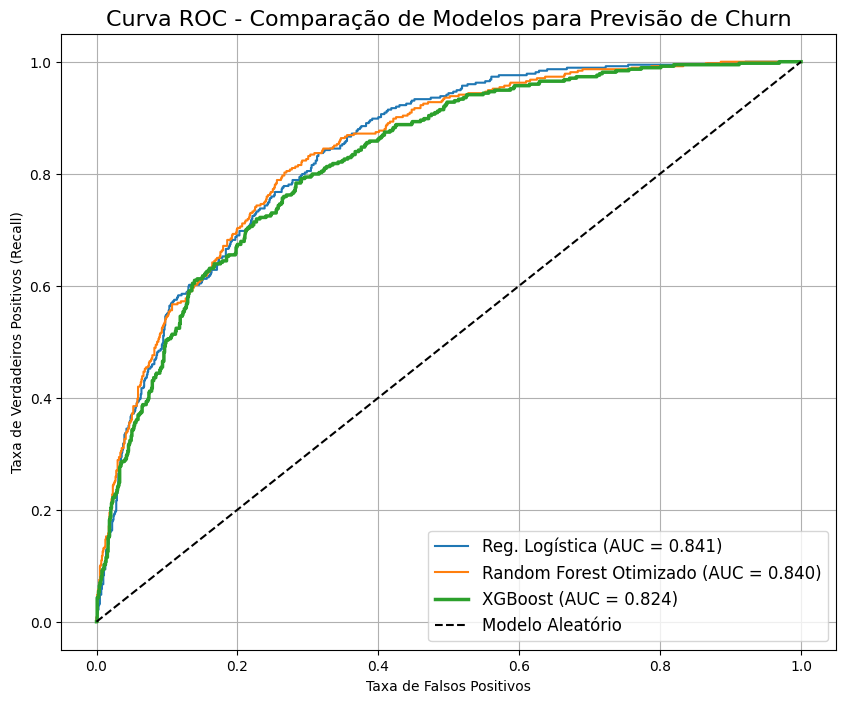

In [13]:
# Célula 9: Comparação Visual com Curva ROC e AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("Gerando a Curva ROC para comparar os melhores modelos...")

# 1. Obter as probabilidades de previsão para a classe 1 (Churn)
prob_log_bal = modelo_log_bal.predict_proba(X_test_scaled)[:, 1]
prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# 2. Calcular a AUC para cada modelo
auc_log_bal = roc_auc_score(y_test, prob_log_bal)
auc_best_rf = roc_auc_score(y_test, prob_best_rf)
auc_xgb = roc_auc_score(y_test, prob_xgb)

print(f"\nAUC Regressão Logística Balanceada: {auc_log_bal:.4f}")
print(f"AUC Random Forest Otimizado: {auc_best_rf:.4f}")
print(f"AUC XGBoost: {auc_xgb:.4f}")

# 3. Calcular os pontos da Curva ROC
fpr_log_bal, tpr_log_bal, _ = roc_curve(y_test, prob_log_bal)
fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test, prob_best_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

# 4. Plotar o gráfico
plt.figure(figsize=(10, 8))
plt.plot(fpr_log_bal, tpr_log_bal, label=f'Reg. Logística (AUC = {auc_log_bal:.3f})')
plt.plot(fpr_best_rf, tpr_best_rf, label=f'Random Forest Otimizado (AUC = {auc_best_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório') # Linha de referência

plt.title('Curva ROC - Comparação de Modelos para Previsão de Churn', fontsize=16)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.legend(fontsize=12)
plt.grid()
plt.show()


In [14]:
# Célula 10: Gerando a Lista de Ação com ID do Cliente

import pandas as pd

print("Identificando os 10 clientes com maior probabilidade de Churn...")

# 1. Usar o nosso melhor modelo para prever as PROBABILIDADES
probabilidades = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Esta linha agora funciona, pois 'df' contém o 'ID_Cliente'
df_resultados = df.loc[X_test.index].copy()
df_resultados['Probabilidade_Churn'] = probabilidades

# 3. Ordenar o DataFrame pela probabilidade de Churn
df_resultados_ordenado = df_resultados.sort_values(by='Probabilidade_Churn', ascending=False)

# 4. Adicionar o 'ID_Cliente' à lista de colunas relevantes
colunas_relevantes = [
    'ID_Cliente',
    'Probabilidade_Churn',
    'Tempo_de_Contrato_Meses',
    'Tipo_de_Contrato',
    'Cobrança_Mensal',
    'Cobrança_Total',
    'Serviço_de_Internet'
]

# 5. Exibir a lista final e acionável
print("\n--- LISTA DE AÇÃO: Top 10 Clientes com Maior Risco de Cancelamento ---")
display(df_resultados_ordenado[colunas_relevantes].head(10))


Identificando os 10 clientes com maior probabilidade de Churn...

--- LISTA DE AÇÃO: Top 10 Clientes com Maior Risco de Cancelamento ---


,ID_Cliente,Probabilidade_Churn,Tempo_de_Contrato_Meses,Tipo_de_Contrato,Cobrança_Mensal,Cobrança_Total,Serviço_de_Internet
4585,1069-XAIEM,0.950381,1,Mês a Mês,85.05,85.05,Fibra Ótica
3380,5178-LMXOP,0.949624,1,Mês a Mês,95.10,95.10,Fibra Ótica
6866,0295-PPHDO,0.942624,1,Mês a Mês,95.45,95.45,Fibra Ótica
2927,5542-TBBWB,0.940392,1,Mês a Mês,69.90,69.90,Fibra Ótica
1739,9804-ICWBG,0.940392,1,Mês a Mês,69.90,69.90,Fibra Ótica
1731,8375-DKEBR,0.939008,1,Mês a Mês,69.60,69.60,Fibra Ótica
809,1820-TQVEV,0.938966,1,Mês a Mês,69.55,69.55,Fibra Ótica
6623,9248-OJYKK,0.938288,1,Mês a Mês,76.45,76.45,Fibra Ótica
3682,3716-BDVDB,0.935738,1,Mês a Mês,69.10,69.10,Fibra Ótica
2464,2609-IAICY,0.926737,1,Mês a Mês,77.15,77.15,Fibra Ótica


In [15]:
# Célula 11: Análise de Churn por Segmento de Valor

print("Analisando o risco de churn por segmento de valor do cliente...")

# Usar o DataFrame de resultados que já criamos na Célula 10
# Criar segmentos de valor baseados na Cobrança Mensal (Ex: dividindo em 4 grupos)
df_resultados_ordenado['Segmento_Valor'] = pd.qcut(
    df_resultados_ordenado['Cobrança_Mensal'],
    q=4,
    labels=['Baixo', 'Médio', 'Alto', 'Premium']
)

# Filtrar para ver apenas os clientes com probabilidade de churn acima de 50%
clientes_em_risco = df_resultados_ordenado[df_resultados_ordenado['Probabilidade_Churn'] > 0.5]

# Contar quantos clientes em risco temos em cada segmento
churn_por_segmento = clientes_em_risco['Segmento_Valor'].value_counts()

print("\nDistribuição de clientes em risco de churn por segmento de valor:")
print(churn_por_segmento)

# Gerar a lista de ação para o segmento mais valioso
print("\n--- LISTA DE AÇÃO PRIORITÁRIA: Top 10 Clientes 'Premium' em Risco de Churn ---")
display(
    clientes_em_risco[clientes_em_risco['Segmento_Valor'] == 'Premium']
    [['ID_Cliente', 'Probabilidade_Churn', 'Cobrança_Mensal', 'Tempo_de_Contrato_Meses']]
    .head(10)
)

Analisando o risco de churn por segmento de valor do cliente...

Distribuição de clientes em risco de churn por segmento de valor:
Segmento_Valor
Alto       219
Premium    159
Médio      114
Baixo       53
Name: count, dtype: int64

--- LISTA DE AÇÃO PRIORITÁRIA: Top 10 Clientes 'Premium' em Risco de Churn ---


,ID_Cliente,Probabilidade_Churn,Cobrança_Mensal,Tempo_de_Contrato_Meses
3380,5178-LMXOP,0.949624,95.10,1
6866,0295-PPHDO,0.942624,95.45,1
2631,6861-XWTWQ,0.926173,99.25,7
3727,9057-SIHCH,0.923460,96.60,3
6365,8884-ADFVN,0.919211,101.95,7
2797,6023-YEBUP,0.918474,100.95,3
1073,0655-RBDUG,0.917062,98.05,7
4039,8161-QYMTT,0.915370,94.10,7
642,0970-ETWGE,0.912652,89.55,1
4678,3006-XIMLN,0.912102,94.20,2


In [16]:
# Célula 12: Calculando o Impacto Financeiro (MRR em Risco)

# Usar o DataFrame de clientes em risco que criamos na célula anterior
mrr_em_risco_total = clientes_em_risco['Cobrança_Mensal'].sum()

# Calcular o MRR em risco apenas dos clientes 'Premium' e 'Alto'
mrr_alto_valor_risco = clientes_em_risco[
    clientes_em_risco['Segmento_Valor'].isin(['Alto', 'Premium'])
]['Cobrança_Mensal'].sum()


print(f"\n--- Análise de Impacto Financeiro ---")
print(f"Receita Mensal Recorrente (MRR) Total em Risco: R$ {mrr_em_risco_total:.2f}")
print(f"MRR em Risco de Clientes de Alto Valor e Premium: R$ {mrr_alto_valor_risco:.2f}")



--- Análise de Impacto Financeiro ---
Receita Mensal Recorrente (MRR) Total em Risco: R$ 40400.00
MRR em Risco de Clientes de Alto Valor e Premium: R$ 32905.55


In [17]:
# Célula 13 (VERSÃO CORRIGIDA): Análise Causa-Raiz no Segmento 'Mês a Mês'

# Usamos 'df' em vez de 'df_original'
df_mes_a_mes = df[df['Tipo_de_Contrato'] == 'Mês a Mês']

# Comparamos o perfil dos que cancelaram vs. os que ficaram DENTRO deste segmento
# Usamos Churn == 1 para 'Sim' e Churn == 0 para 'Não'
perfil_churn_mes_a_mes = df_mes_a_mes[df_mes_a_mes['Churn'] == 1].describe()
perfil_ficam_mes_a_mes = df_mes_a_mes[df_mes_a_mes['Churn'] == 0].describe()

print("\n--- Análise: Perfil de Clientes com Contrato 'Mês a Mês' ---")
print("\nPerfil médio de quem CANCELOU:")
display(perfil_churn_mes_a_mes[['Tempo_de_Contrato_Meses', 'Cobrança_Mensal']])

print("\nPerfil médio de quem FICOU:")
display(perfil_ficam_mes_a_mes[['Tempo_de_Contrato_Meses', 'Cobrança_Mensal']])



--- Análise: Perfil de Clientes com Contrato 'Mês a Mês' ---

Perfil médio de quem CANCELOU:


,Tempo_de_Contrato_Meses,Cobrança_Mensal
count,1655.000000,1655.000000
mean,14.016918,73.019396
std,15.828615,24.084146
min,1.000000,18.850000
25%,2.000000,55.200000
50%,7.000000,79.050000
75%,21.000000,90.875000
max,71.000000,117.450000



Perfil médio de quem FICOU:


,Tempo_de_Contrato_Meses,Cobrança_Mensal
count,2220.000000,2220.000000
mean,21.033333,61.462635
std,18.398051,27.863547
min,1.000000,18.750000
25%,5.000000,38.537500
50%,16.000000,64.950000
75%,33.000000,84.912500
max,72.000000,116.500000


In [18]:
# Célula 14: Célula para Relatório: Usando Plotly para Gráficos Interativos

import plotly.express as px

# Reutilizar o cálculo que já fizemos
churn_por_pagamento = df.groupby('Método_de_Pagamento')['Churn'].mean().sort_values(ascending=False) * 100
df_plot = churn_por_pagamento.reset_index()

# Criar o gráfico com Plotly Express
fig = px.bar(
    df_plot,
    x='Método_de_Pagamento',
    y='Churn',
    title='Taxa de Churn por Método de Pagamento',
    labels={'Churn': 'Taxa de Churn (%)', 'Método_de_Pagamento': 'Método de Pagamento'},
    text_auto='.2f' # Formata o texto para 2 casas decimais
)

# Melhorar o layout
fig.update_layout(
    title_font_size=22,
    xaxis_title_font_size=16,
    yaxis_title_font_size=16,
)

# Exibir o gráfico interativo
fig.show()


Analisando a taxa de churn em diferentes estágios da jornada do cliente...

--- Taxa de Churn (%) por Tempo de Contrato ---
Faixa_de_Contrato
0-12 Meses     48.28
13-24 Meses    29.51
25-36 Meses    22.03
37-48 Meses    19.52
49-60 Meses    15.00
61-72 Meses     8.30
Name: Churn, dtype: float64


/tmp/ipython-input-1658015768.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-1658015768.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




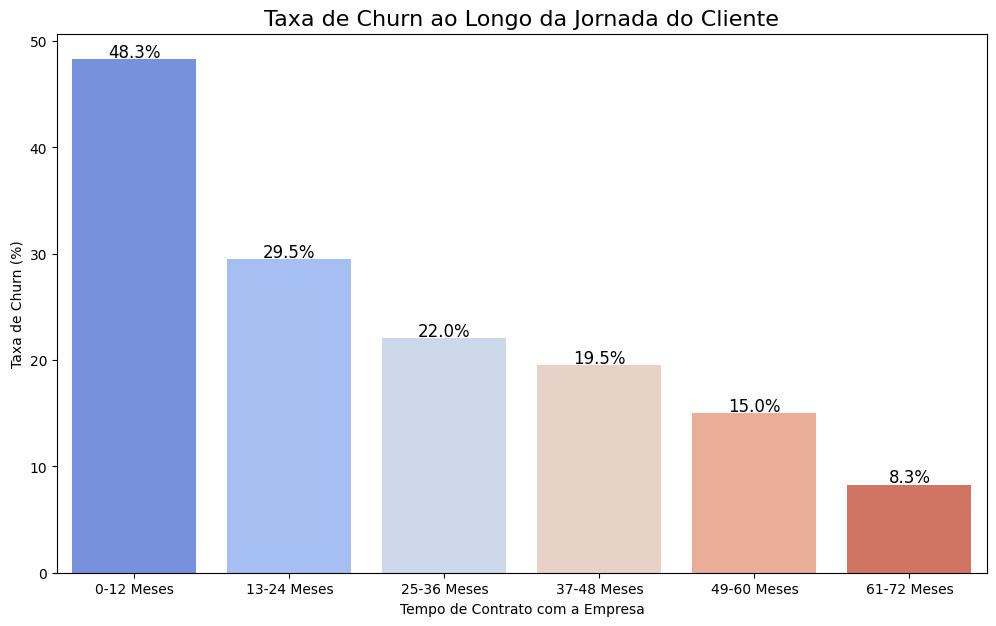

In [19]:
# Célula 15: Análise da Taxa de Churn pela Jornada do Cliente (Tempo de Contrato)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Analisando a taxa de churn em diferentes estágios da jornada do cliente...")

# Criar "faixas" de tempo de contrato para agrupar os clientes
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 Meses', '13-24 Meses', '25-36 Meses', '37-48 Meses', '49-60 Meses', '61-72 Meses']
df['Faixa_de_Contrato'] = pd.cut(df['Tempo_de_Contrato_Meses'], bins=bins, labels=labels, right=False)

# Calcular a taxa de churn para cada faixa
churn_por_jornada = df.groupby('Faixa_de_Contrato')['Churn'].mean().sort_index() * 100

print("\n--- Taxa de Churn (%) por Tempo de Contrato ---")
print(churn_por_jornada.round(2))

# Visualizar os resultados
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=churn_por_jornada.index, y=churn_por_jornada.values, palette='coolwarm')
plt.title('Taxa de Churn ao Longo da Jornada do Cliente', fontsize=16)
plt.ylabel('Taxa de Churn (%)')
plt.xlabel('Tempo de Contrato com a Empresa')

# Adicionar os valores no topo das barras para clareza
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


In [20]:
# Célula 16: Análise de Receita por Tipo de Contrato

print("Analisando a receita e o churn por tipo de contrato...")

# Agrupar por tipo de contrato e calcular a receita total e a taxa de churn
analise_contrato = df.groupby('Tipo_de_Contrato').agg(
    Receita_Mensal_Total=('Cobrança_Mensal', 'sum'),
    Numero_de_Clientes=('ID_Cliente', 'count'),
    Taxa_de_Churn=('Churn', 'mean')
).sort_values(by='Receita_Mensal_Total', ascending=False)

analise_contrato['Taxa_de_Churn'] = analise_contrato['Taxa_de_Churn'] * 100

print("\n--- Análise Financeira por Tipo de Contrato ---")
display(analise_contrato.round(2))

Analisando a receita e o churn por tipo de contrato...

--- Análise Financeira por Tipo de Contrato ---


,Receita_Mensal_Total,Numero_de_Clientes,Taxa_de_Churn
Tipo_de_Contrato,,,
Mês a Mês,257294.15,3875,42.71
Dois Anos,103005.85,1695,2.83
Anual,95816.60,1473,11.27


In [21]:
# Célula 17: Célula: Gerar Relatório HTML Consolidado
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import json

# Dependências para métricas e gráficos
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, classification_report
)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# 1) KPIs básicos do dataset
sections = []

def safe_exists(var_name: str) -> bool:
    return var_name in globals()

now_str = datetime.now().strftime('%Y-%m-%d %H:%M')
project_dir = Path.cwd()
report_path = project_dir / 'relatorio_churn.html'

# Informações básicas
try:
    n_rows, n_cols = df.shape
    churn_rate = float(df['Churn'].mean() * 100) if 'Churn' in df.columns else float('nan')
    churn_counts = df['Churn'].value_counts().to_dict() if 'Churn' in df.columns else {}
    kpis_html = f'''
    <section>
      <h2>Visão Geral</h2>
      <ul>
        <li>Linhas: <b>{n_rows:,}</b> • Colunas: <b>{n_cols}</b></li>
        <li>Taxa de Churn: <b>{churn_rate:.2f}%</b></li>
        <li>Distribuição Churn (0/1): <code>{json.dumps(churn_counts, ensure_ascii=False)}</code></li>
        <li>Gerado em: {now_str}</li>
      </ul>
    </section>
    '''
    sections.append(kpis_html)
except Exception as e:
    sections.append(f"<p><b>Falha ao calcular KPIs:</b> {e}</p>")

# 2) Gráfico: Churn por Método de Pagamento (se houver)
try:
    if set(['Método_de_Pagamento','Churn']).issubset(df.columns):
        churn_por_pagamento = df.groupby('Método_de_Pagamento')['Churn'].mean().sort_values(ascending=False) * 100
        df_plot = churn_por_pagamento.reset_index().rename(columns={'Churn':'Taxa de Churn (%)'})
        fig_pay = px.bar(
            df_plot, x='Método_de_Pagamento', y='Taxa de Churn (%)',
            title='Taxa de Churn por Método de Pagamento', text='Taxa de Churn (%)'
        )
        fig_pay.update_traces(texttemplate='%{text:.2f}', textposition='outside')
        fig_pay.update_layout(margin=dict(t=60,l=40,r=40,b=40))
        div_pay = pio.to_html(fig_pay, include_plotlyjs='cdn', full_html=False, div_id='fig_pagamento')
        sections.append('<section><h2>Churn por Método de Pagamento</h2>' + div_pay + '</section>')
except Exception as e:
    sections.append(f"<p><b>Falha ao gerar gráfico por pagamento:</b> {e}</p>")

# 3) Métricas de modelos e Curva ROC (se variáveis existirem)
roc_fig = go.Figure()
roc_any = False
metrics_rows = []

try:
    # Garantir dados de teste escalados/originais quando necessário
    have_test_scaled = safe_exists('X_test_scaled') and safe_exists('y_test')
    have_test = safe_exists('X_test') and safe_exists('y_test')

    # a) Regressão Logística (balanceada)
    if safe_exists('modelo_log_bal') and have_test_scaled:
        from numpy import ndarray
        y_pred = modelo_log_bal.predict(X_test_scaled)
        y_proba = getattr(modelo_log_bal, 'predict_proba')(X_test_scaled)[:,1]
        metrics_rows.append({
            'Modelo':'Reg. Logística (bal.)',
            'Acurácia': accuracy_score(y_test, y_pred),
            'Precisão': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'AUC': roc_auc_score(y_test, y_proba)
        })
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='Reg. Logística'))
        roc_any = True

    # b) Random Forest (melhor via busca)
    if safe_exists('best_rf_model') and have_test:
        y_pred = best_rf_model.predict(X_test)
        y_proba = best_rf_model.predict_proba(X_test)[:,1]
        metrics_rows.append({
            'Modelo':'Random Forest (best)',
            'Acurácia': accuracy_score(y_test, y_pred),
            'Precisão': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'AUC': roc_auc_score(y_test, y_proba)
        })
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='Random Forest'))
        roc_any = True

    # c) XGBoost
    if safe_exists('modelo_xgb') and have_test:
        y_pred = modelo_xgb.predict(X_test)
        # Garantir proba
        y_proba = modelo_xgb.predict_proba(X_test)[:,1] if hasattr(modelo_xgb, 'predict_proba') else None
        auc_val = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
        metrics_rows.append({
            'Modelo':'XGBoost',
            'Acurácia': accuracy_score(y_test, y_pred),
            'Precisão': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'AUC': auc_val
        })
        if y_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='XGBoost'))
            roc_any = True

    # Montar tabela de métricas
    if metrics_rows:
        df_metrics = pd.DataFrame(metrics_rows)
        df_metrics['Acurácia'] = (df_metrics['Acurácia']*100).round(2)
        df_metrics['Precisão'] = (df_metrics['Precisão']*100).round(2)
        df_metrics['Recall'] = (df_metrics['Recall']*100).round(2)
        df_metrics['F1'] = (df_metrics['F1']*100).round(2)
        if df_metrics['AUC'].notna().any():
            df_metrics['AUC'] = df_metrics['AUC'].apply(lambda v: round(v,4) if pd.notna(v) else '')
        table_html = df_metrics.to_html(index=False)
        sections.append('<section><h2>Métricas de Modelos</h2>'+table_html+'</section>')

    # Curva ROC
    if roc_any:
        roc_fig.update_layout(title='Curvas ROC', xaxis_title='FPR', yaxis_title='TPR',
                              margin=dict(t=60,l=40,r=40,b=40))
        roc_div = pio.to_html(roc_fig, include_plotlyjs='cdn', full_html=False, div_id='fig_roc')
        sections.append('<section><h2>Curvas ROC</h2>'+roc_div+'</section>')
except Exception as e:
    sections.append(f"<p><b>Falha ao calcular métricas/ROC:</b> {e}</p>")

# 4) Top 10 clientes em maior risco (se disponível)
try:
    top_table_html = ''
    if not safe_exists('df_resultados_ordenado') and safe_exists('best_rf_model') and safe_exists('X_test') and 'ID_Cliente' in df.columns:
        # Recalcular rapidamente a tabela de resultados se necessário
        probs = best_rf_model.predict_proba(X_test)[:,1]
        df_resultados = df.loc[X_test.index].copy()
        df_resultados['Probabilidade_Churn'] = probs
        df_resultados_ordenado = df_resultados.sort_values(by='Probabilidade_Churn', ascending=False)
    if safe_exists('df_resultados_ordenado'):
        cols = [c for c in ['ID_Cliente','Probabilidade_Churn','Tempo_de_Contrato_Meses','Tipo_de_Contrato','Cobrança_Mensal','Cobrança_Total'] if c in df_resultados_ordenado.columns]
        top_table_html = df_resultados_ordenado[cols].head(10).to_html(index=False)
        sections.append('<section><h2>Top 10 Clientes com Maior Risco</h2>'+top_table_html+'</section>')
except Exception as e:
    sections.append(f"<p><b>Falha ao gerar Top 10:</b> {e}</p>")

# 5) Montagem final do HTML
html = f'''
<!DOCTYPE html>
<html lang="pt-br">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>Relatório de Churn</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; }}
    h1 {{ margin-bottom: 0; }}
    h2 {{ margin-top: 32px; }}
    section {{ margin-bottom: 24px; }}
    table {{ border-collapse: collapse; width: 100%; }}
    table, th, td {{ border: 1px solid #ddd; }}
    th, td {{ padding: 8px; text-align: left; }}
    th {{ background: #f5f5f5; }}
  </style>
</head>
<body>
  <h1>Relatório de Churn</h1>
  <p><small>Gerado em {now_str}</small></p>
  {''.join(sections)}
</body>
</html>
'''

# 6) Salvar arquivo
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f"Relatório salvo em: {report_path}")

Relatório salvo em: /content/relatorio_churn.html


In [22]:
# Célula 17

# Célula: Seleção de Modelo e Probabilidades para Previsão
import numpy as np
from typing import Tuple, Optional

print("Preparando o modelo e as probabilidades para análises preditivas...")

best_model = None
X_eval = None
use_scaled = False

# Seleção de modelo com base no que está disponível no kernel
if 'best_rf_model' in globals():
    best_model = best_rf_model
    X_eval = X_test if 'X_test' in globals() else None
    use_scaled = False
    print("Modelo selecionado: Random Forest (best)")
elif 'modelo_xgb' in globals():
    best_model = modelo_xgb
    X_eval = X_test if 'X_test' in globals() else None
    use_scaled = False
    print("Modelo selecionado: XGBoost")
elif 'modelo_log_bal' in globals():
    best_model = modelo_log_bal
    X_eval = X_test_scaled if 'X_test_scaled' in globals() else None
    use_scaled = True
    print("Modelo selecionado: Regressão Logística (balanceada)")
else:
    print("Nenhum modelo encontrado. Execute as células de treinamento antes desta.")

if best_model is not None and 'y_test' in globals() and X_eval is not None:
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_eval)[:, 1]
    else:
        # fallback para decisões como pontuações; normaliza para [0,1]
        scores = best_model.decision_function(X_eval)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    print("Probabilidades calculadas com sucesso.")
else:
    y_proba = None
    print("Impossível calcular probabilidades: verifique X_test/X_test_scaled e y_test.")


Preparando o modelo e as probabilidades para análises preditivas...
Modelo selecionado: Random Forest (best)
Probabilidades calculadas com sucesso.


In [23]:
# Celula 18: Célula: Curvas ROC / Precision-Recall e Threshold Ótimo (F1)
from sklearn.metrics import roc_curve, precision_recall_curve, auc, f1_score
import plotly.graph_objects as go

if 'y_test' in globals() and 'y_proba' in globals() and y_proba is not None:
    # ROC
    fpr, tpr, thr_roc = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # PR
    precision, recall, thr_pr = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)

    # Threshold ótimo por F1 (varrendo thresholds de 0.01 em 0.99)
    thresholds = np.linspace(0.01, 0.99, 99)
    f1s = []
    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        f1s.append(f1_score(y_test, y_hat, zero_division=0))
    best_idx = int(np.argmax(f1s))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1s[best_idx])

    # Plot ROC
    fig_roc = go.Figure()
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC={roc_auc:.3f})'))
    fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Aleatório', line=dict(dash='dash')))
    fig_roc.update_layout(title='Curva ROC', xaxis_title='FPR', yaxis_title='TPR')
    fig_roc.show()

    # Plot Precision-Recall + F1
    fig_pr = go.Figure()
    fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=f'PR (AUC={pr_auc:.3f})'))
    fig_pr.update_layout(title='Curva Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão')
    fig_pr.show()

    fig_f1 = go.Figure()
    fig_f1.add_trace(go.Scatter(x=thresholds, y=f1s, mode='lines+markers', name='F1 vs Threshold'))
    fig_f1.add_trace(go.Scatter(x=[best_threshold], y=[best_f1], mode='markers', marker=dict(size=10, color='red'), name='Melhor F1'))
    fig_f1.update_layout(title='Seleção de Threshold por F1', xaxis_title='Threshold', yaxis_title='F1')
    fig_f1.show()

    print(f"Threshold ótimo (F1): {best_threshold:.3f} | F1: {best_f1:.3f} | ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")
else:
    best_threshold = None
    print("Probabilidades ou y_test indisponíveis. Execute as células anteriores.")


Threshold ótimo (F1): 0.460 | F1: 0.631 | ROC AUC: 0.840 | PR AUC: 0.652


In [24]:
# Célula 19: Célula: Matriz de Confusão e Métricas no Threshold Ótimo
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import plotly.express as px

if 'y_test' in globals() and 'y_proba' in globals() and y_proba is not None and 'best_threshold' in globals() and best_threshold is not None:
    y_pred_thr = (y_proba >= best_threshold).astype(int)

    acc = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    rec = recall_score(y_test, y_pred_thr, zero_division=0)
    f1 = f1_score(y_test, y_pred_thr, zero_division=0)

    cm = confusion_matrix(y_test, y_pred_thr)
    cm_df = pd.DataFrame(cm, index=['Real 0','Real 1'], columns=['Pred 0','Pred 1'])
    print("Matriz de Confusão:")
    display(cm_df)

    print(f"\nAcurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

    fig_cm = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues', title='Matriz de Confusão')
    fig_cm.update_layout(margin=dict(t=60,l=40,r=40,b=40))
    fig_cm.show()
else:
    print("Não foi possível calcular a matriz de confusão. Verifique as células anteriores.")


Matriz de Confusão:


,Pred 0,Pred 1
Real 0,756,279
Real 1,73,301



Acurácia: 0.750 | Precisão: 0.519 | Recall: 0.805 | F1: 0.631


In [25]:
# Célula 20: Célula: Importância de Features (Top 20)
import numpy as np
import pandas as pd
import plotly.express as px

if 'best_model' in globals() and best_model is not None:
    feature_names = list(X_encoded.columns) if 'X_encoded' in globals() else None
    importances = None

    if hasattr(best_model, 'feature_importances_') and feature_names is not None:
        importances = best_model.feature_importances_
        title = 'Importâncias de Features (modelo árvore)'
    else:
        # Tentar permutation_importance se possível e se tivermos X_eval/y_test
        try:
            from sklearn.inspection import permutation_importance
            if 'X_test' in globals() and 'y_test' in globals() and feature_names is not None:
                result = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
                importances = result.importances_mean
                title = 'Importâncias por Permutação'
        except Exception as e:
            print('Falha ao calcular importâncias por permutação:', e)

    if importances is not None and feature_names is not None:
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        imp_top = imp_df.sort_values('importance', ascending=False).head(20)
        fig_imp = px.bar(imp_top.sort_values('importance'), x='importance', y='feature', orientation='h', title=title)
        fig_imp.update_layout(margin=dict(t=60,l=40,r=40,b=40))
        fig_imp.show()
    else:
        print('Não foi possível obter importâncias de features com o modelo atual.')
else:
    print('Nenhum modelo disponível para calcular importâncias.')


In [26]:
# Célula 21: Salvar Artefatos do Modelo para Produção
from pathlib import Path
import joblib
from datetime import datetime

artefatos_dir = Path.cwd() / 'artefatos_modelo'
artefatos_dir.mkdir(exist_ok=True)

meta = {
    'gerado_em': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'modelo': type(best_model).__name__ if 'best_model' in globals() and best_model is not None else None,
    'threshold': float(best_threshold) if 'best_threshold' in globals() and best_threshold is not None else None,
    'use_scaled': bool(use_scaled) if 'use_scaled' in globals() else False,
}

if 'best_model' in globals() and best_model is not None:
    joblib.dump(best_model, artefatos_dir / 'modelo.joblib')
    print('Modelo salvo em', artefatos_dir / 'modelo.joblib')

if 'scaler' in globals():
    joblib.dump(scaler, artefatos_dir / 'scaler.joblib')
    print('Scaler salvo em', artefatos_dir / 'scaler.joblib')

if 'X_encoded' in globals():
    joblib.dump(list(X_encoded.columns), artefatos_dir / 'colunas_X_encoded.joblib')
    print('Colunas de X_encoded salvas em', artefatos_dir / 'colunas_X_encoded.joblib')

joblib.dump(meta, artefatos_dir / 'metadata.joblib')
print('Metadata salva em', artefatos_dir / 'metadata.joblib')


Modelo salvo em /content/artefatos_modelo/modelo.joblib
Scaler salvo em /content/artefatos_modelo/scaler.joblib
Colunas de X_encoded salvas em /content/artefatos_modelo/colunas_X_encoded.joblib
Metadata salva em /content/artefatos_modelo/metadata.joblib


In [27]:
# Célula 22: Calibração de Probabilidades (CalibratedClassifierCV)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.metrics import brier_score_loss
import numpy as np

if 'best_model' in globals() and best_model is not None and 'y_test' in globals():
    # Selecionar matrizes corretas (escaladas ou não)
    X_train_eval = X_train_scaled if ('X_train_scaled' in globals() and use_scaled) else X_train
    X_test_eval  = X_test_scaled  if ('X_test_scaled' in globals() and use_scaled) else X_test

    if X_train_eval is None or X_test_eval is None:
        print('Dados de treino/teste não encontrados para calibração.')
    else:
        print('Iniciando calibração (sigmoid, cv=3)...')
        base = clone(best_model)
        calibrator = CalibratedClassifierCV(estimator=base, cv=3, method='sigmoid')
        calibrator.fit(X_train_eval, y_train)

        # Probabilidades originais vs calibradas
        y_proba_orig = y_proba if 'y_proba' in globals() and y_proba is not None else (
            best_model.predict_proba(X_test_eval)[:,1] if hasattr(best_model,'predict_proba') else None
        )
        y_proba_cal = calibrator.predict_proba(X_test_eval)[:,1]

        # Brier score: menor é melhor
        brier_orig = brier_score_loss(y_test, y_proba_orig) if y_proba_orig is not None else np.inf
        brier_cal  = brier_score_loss(y_test, y_proba_cal)
        print(f'Brier (orig): {brier_orig:.4f} | Brier (cal): {brier_cal:.4f}')

        # Threshold ótimo por F1 com probabilidades calibradas
        thresholds = np.linspace(0.01, 0.99, 99)
        f1s = []
        for t in thresholds:
            y_hat = (y_proba_cal >= t).astype(int)
            f1s.append(f1_score(y_test, y_hat, zero_division=0))
        best_idx = int(np.argmax(f1s))
        best_threshold_cal = float(thresholds[best_idx])
        best_f1_cal = float(f1s[best_idx])
        print(f'Threshold ótimo (calibrado) = {best_threshold_cal:.3f} | F1 (cal) = {best_f1_cal:.3f}')

        # Adotar calibrado se Brier melhorar
        if brier_cal < brier_orig:
            print('Adotando modelo calibrado para etapas seguintes.')
            best_model = calibrator
            y_proba = y_proba_cal
            best_threshold = best_threshold_cal
        else:
            print('Mantendo probabilidades originais (calibração não melhorou Brier).')
else:
    print('Modelo ou y_test indisponíveis; execute as células anteriores.')


Iniciando calibração (sigmoid, cv=3)...
Brier (orig): 0.1588 | Brier (cal): 0.1369
Threshold ótimo (calibrado) = 0.330 | F1 (cal) = 0.634
Adotando modelo calibrado para etapas seguintes.


In [28]:
# Célula 23: Funções de Inferência (carrega artefatos e prevê para um registro)
from pathlib import Path
import joblib
import pandas as pd

ARTEFATOS_DIR = Path.cwd() / 'artefatos_modelo'

def carregar_artefatos():
    modelo_path = ARTEFATOS_DIR / 'modelo.joblib'
    scaler_path = ARTEFATOS_DIR / 'scaler.joblib'
    cols_path   = ARTEFATOS_DIR / 'colunas_X_encoded.joblib'
    meta_path   = ARTEFATOS_DIR / 'metadata.joblib'

    modelo = joblib.load(modelo_path) if modelo_path.exists() else (best_model if 'best_model' in globals() else None)
    scaler = joblib.load(scaler_path) if scaler_path.exists() else (scaler if 'scaler' in globals() else None)
    colunas = joblib.load(cols_path) if cols_path.exists() else (list(X_encoded.columns) if 'X_encoded' in globals() else None)
    meta = joblib.load(meta_path) if meta_path.exists() else {'threshold': best_threshold if 'best_threshold' in globals() else 0.5, 'use_scaled': bool(use_scaled) if 'use_scaled' in globals() else False}
    return modelo, scaler, colunas, meta


def preparar_features(registro: dict, colunas_fit: list) -> pd.DataFrame:
    df_input = pd.DataFrame([registro])
    X_enc = pd.get_dummies(df_input, drop_first=True)
    X_enc = X_enc.reindex(columns=colunas_fit, fill_value=0)
    return X_enc


def prever_churn(registro: dict):
    modelo, scaler_obj, colunas_fit, meta = carregar_artefatos()
    if modelo is None or colunas_fit is None:
        raise RuntimeError('Artefatos insuficientes para inferência. Treine/salve o modelo primeiro.')
    X_enc = preparar_features(registro, colunas_fit)
    # Aplicar scaler apenas se o pipeline do modelo exigir
    if meta.get('use_scaled', False) and scaler_obj is not None:
        X_eval = scaler_obj.transform(X_enc)
    else:
        X_eval = X_enc
    proba = modelo.predict_proba(X_eval)[:,1] if hasattr(modelo,'predict_proba') else modelo.predict(X_eval)
    thr = float(meta.get('threshold', 0.5))
    pred = (proba >= thr).astype(int)
    return float(proba[0]), int(pred[0]), thr

# Exemplo de uso (utilizando o primeiro registro de df, excluindo colunas alvo/ID)
try:
    exemplo = df.drop(columns=[c for c in ['Churn','ID_Cliente'] if c in df.columns]).iloc[0].to_dict()
    p, yhat, thr = prever_churn(exemplo)
    print(f"Exemplo -> Prob: {p:.3f} | Classe (thr={thr:.3f}): {yhat}")
except Exception as e:
    print('Não foi possível executar exemplo de inferência:', e)


Exemplo -> Prob: 0.480 | Classe (thr=0.460): 1


In [29]:
# Célula 24: Atualizar Relatório HTML com Análises Preditivas
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, auc, confusion_matrix
)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

sections = []
now_str = datetime.now().strftime('%Y-%m-%d %H:%M')
project_dir = Path.cwd()
report_path = project_dir / 'relatorio_churn.html'

# 1) KPIs básicos
try:
    n_rows, n_cols = df.shape
    churn_rate = float(df['Churn'].mean() * 100) if 'Churn' in df.columns else float('nan')
    churn_counts = df['Churn'].value_counts().to_dict() if 'Churn' in df.columns else {}
    kpis_html = f'''
    <section>
      <h2>Visão Geral</h2>
      <ul>
        <li>Linhas: <b>{n_rows:,}</b> • Colunas: <b>{n_cols}</b></li>
        <li>Taxa de Churn: <b>{churn_rate:.2f}%</b></li>
        <li>Distribuição Churn (0/1): <code>{json.dumps(churn_counts, ensure_ascii=False)}</code></li>
        <li>Gerado em: {now_str}</li>
      </ul>
    </section>
    '''
    sections.append(kpis_html)
except Exception as e:
    sections.append(f"<p><b>Falha ao calcular KPIs:</b> {e}</p>")

# 2) Churn por Método de Pagamento
try:
    if set(['Método_de_Pagamento','Churn']).issubset(df.columns):
        churn_por_pagamento = df.groupby('Método_de_Pagamento')['Churn'].mean().sort_values(ascending=False) * 100
        df_plot = churn_por_pagamento.reset_index().rename(columns={'Churn':'Taxa de Churn (%)'})
        fig_pay = px.bar(df_plot, x='Método_de_Pagamento', y='Taxa de Churn (%)', title='Taxa de Churn por Método de Pagamento', text='Taxa de Churn (%)')
        fig_pay.update_traces(texttemplate='%{text:.2f}', textposition='outside')
        fig_pay.update_layout(margin=dict(t=60,l=40,r=40,b=40))
        div_pay = pio.to_html(fig_pay, include_plotlyjs='cdn', full_html=False, div_id='fig_pagamento')
        sections.append('<section><h2>Churn por Método de Pagamento</h2>' + div_pay + '</section>')
except Exception as e:
    sections.append(f"<p><b>Falha ao gerar gráfico por pagamento:</b> {e}</p>")

# 3) Métricas + Curvas (se disponíveis)
try:
    if 'y_test' in globals() and 'y_proba' in globals() and y_proba is not None:
        # ROC/PR
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_auc = auc(recall, precision)

        fig_roc = go.Figure()
        fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC={roc_auc:.3f})'))
        fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Aleatório', line=dict(dash='dash')))
        fig_roc.update_layout(title='Curva ROC', xaxis_title='FPR', yaxis_title='TPR', margin=dict(t=60,l=40,r=40,b=40))
        roc_div = pio.to_html(fig_roc, include_plotlyjs='cdn', full_html=False, div_id='fig_roc_html')

        fig_pr = go.Figure()
        fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=f'PR (AUC={pr_auc:.3f})'))
        fig_pr.update_layout(title='Curva Precision-Recall', xaxis_title='Recall', yaxis_title='Precisão', margin=dict(t=60,l=40,r=40,b=40))
        pr_div = pio.to_html(fig_pr, include_plotlyjs=False, full_html=False, div_id='fig_pr_html')

        # Threshold e matriz de confusão
        thr = float(best_threshold) if 'best_threshold' in globals() and best_threshold is not None else 0.5
        y_pred_thr = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_test, y_pred_thr)
        acc = accuracy_score(y_test, y_pred_thr)
        prec = precision_score(y_test, y_pred_thr, zero_division=0)
        rec = recall_score(y_test, y_pred_thr, zero_division=0)
        f1 = f1_score(y_test, y_pred_thr, zero_division=0)
        cm_df = pd.DataFrame(cm, index=['Real 0','Real 1'], columns=['Pred 0','Pred 1'])
        cm_table = cm_df.to_html()

        metrics_html = f'''
        <section>
          <h2>Métricas de Classificação (threshold={thr:.3f})</h2>
          <ul>
            <li>Acurácia: <b>{acc:.3f}</b></li>
            <li>Precisão: <b>{prec:.3f}</b></li>
            <li>Recall: <b>{rec:.3f}</b></li>
            <li>F1: <b>{f1:.3f}</b></li>
            <li>ROC AUC: <b>{roc_auc:.3f}</b> • PR AUC: <b>{pr_auc:.3f}</b></li>
          </ul>
          <h3>Matriz de Confusão</h3>
          {cm_table}
          <h3>Curvas</h3>
          {roc_div}
          {pr_div}
        </section>
        '''
        sections.append(metrics_html)
except Exception as e:
    sections.append(f"<p><b>Falha ao gerar métricas/curvas:</b> {e}</p>")

# 4) Top 10 clientes em risco (se disponível)
try:
    if 'df_resultados_ordenado' in globals():
        cols = [c for c in ['ID_Cliente','Probabilidade_Churn','Tempo_de_Contrato_Meses','Tipo_de_Contrato','Cobrança_Mensal','Cobrança_Total'] if c in df_resultados_ordenado.columns]
        top_table_html = df_resultados_ordenado[cols].head(10).to_html(index=False)
        sections.append('<section><h2>Top 10 Clientes com Maior Risco</h2>'+top_table_html+'</section>')
except Exception as e:
    sections.append(f"<p><b>Falha ao gerar Top 10:</b> {e}</p>")

# 5) Montagem final e salvar
html = f'''
<!DOCTYPE html>
<html lang="pt-br">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>Relatório de Churn</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; }}
    h1 {{ margin-bottom: 0; }}
    h2 {{ margin-top: 32px; }}
    section {{ margin-bottom: 24px; }}
    table {{ border-collapse: collapse; width: 100%; }}
    table, th, td {{ border: 1px solid #ddd; }}
    th, td {{ padding: 8px; text-align: left; }}
    th {{ background: #f5f5f5; }}
  </style>
</head>
<body>
  <h1>Relatório de Churn</h1>
  <p><small>Gerado em {now_str}</small></p>
  {''.join(sections)}
</body>
</html>
'''

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f'Relatório atualizado salvo em: {report_path}')


Relatório atualizado salvo em: /content/relatorio_churn.html


In [30]:
# Célula 25: Curva de Calibração (Reliability Diagram) e Brier Score
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import plotly.graph_objects as go

if 'y_test' in globals() and 'y_proba' in globals() and y_proba is not None:
    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test, y_proba)

    fig_cal = go.Figure()
    fig_cal.add_trace(go.Scatter(x=mean_pred, y=frac_pos, mode='lines+markers', name='Calibração'))
    fig_cal.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Perfeita', line=dict(dash='dash')))
    fig_cal.update_layout(title=f'Curva de Calibração (Brier={brier:.3f})', xaxis_title='Probabilidade prevista', yaxis_title='Frequência observada')
    fig_cal.show()
    print(f"Brier Score: {brier:.4f}")
else:
    print('Probabilidades/y_test indisponíveis. Execute as células anteriores.')


Brier Score: 0.1369


In [31]:
# Célula 26: Threshold Ótimo por Custo (defina seus custos/benefícios)
import numpy as np
from sklearn.metrics import confusion_matrix

# Ajuste estes valores para sua realidade de negócio
custo_fp = 10.0   # custo de abordar um cliente que não sairia
custo_fn = 200.0  # custo de perder um cliente que sairia (perda de receita)
beneficio_tp = 150.0  # benefício ao reter com sucesso um cliente que sairia

if 'y_test' in globals() and 'y_proba' in globals() and y_proba is not None:
    thresholds = np.linspace(0.01, 0.99, 99)
    custos = []

    for t in thresholds:
        y_hat = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
        # Custo esperado: penaliza FP/FN e subtrai benefício dos TP
        custo = (fp * custo_fp) + (fn * custo_fn) - (tp * beneficio_tp)
        custos.append(custo)

    i_best = int(np.argmin(custos))
    t_best = float(thresholds[i_best])
    custo_best = float(custos[i_best])
    print(f"Threshold ótimo por custo: {t_best:.3f} | Custo esperado: {custo_best:.2f}")
    # manter disponível para outras células
    threshold_custo = t_best
else:
    print('Probabilidades/y_test indisponíveis. Execute as células anteriores.')


Threshold ótimo por custo: 0.040 | Custo esperado: -47070.00


In [36]:
# Célula 27 (renomeada para melhor clareza): SHAP - Explicabilidade do Modelo (Top 20 Features)

import shap
import numpy as np
import pandas as pd
import plotly.express as px

# Escolher um modelo de árvore para SHAP (prioriza XGBoost, depois RandomForest)
shap_model = None
shap_X = None
feature_names = list(X_encoded.columns) if 'X_encoded' in globals() else None

if 'modelo_xgb' in globals():
    shap_model = modelo_xgb
    shap_X = X_test if 'X_test' in globals() else None
elif 'best_rf_model' in globals():
    shap_model = best_rf_model
    shap_X = X_test if 'X_test' in globals() else None
else:
    # fallback: tentar usar best_model se for árvore
    shap_model = best_model if 'best_model' in globals() else None
    shap_X = X_test if 'X_test' in globals() else None

if shap_model is not None and shap_X is not None and feature_names is not None:
    try:
        # Para modelos de árvore, TreeExplainer é rápido
        explainer = shap.TreeExplainer(shap_model)

        # Amostra para agilizar
        # A conversão para DataFrame garante que tenhamos os nomes das colunas corretos
        X_sample_df = pd.DataFrame(X_test, columns=feature_names)
        X_sample = X_sample_df.sample(n=min(500, X_test.shape[0]), random_state=42)

        # --- CORREÇÃO APLICADA AQUI ---
        # Convertendo explicitamente os dados para o tipo float para evitar o ValueError
        shap_values = explainer.shap_values(X_sample.astype(float))

        # SHAP pode retornar lista (para multiclass); em binário usamos o componente 1 se aplicável
        if isinstance(shap_values, list) and len(shap_values) > 1:
            shap_vals = shap_values[1]
        else:
            shap_vals = shap_values

        # Importância média absoluta
        mean_abs = np.abs(shap_vals).mean(axis=0)
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': mean_abs})
        imp_top = imp_df.sort_values('importance', ascending=False).head(20)

        fig_shap = px.bar(
            imp_top.sort_values('importance'),
            x='importance',
            y='feature',
            orientation='h',
            title='SHAP Importância de Features (Top 20)'
        )
        fig_shap.update_layout(margin=dict(t=60, l=40, r=40, b=40))
        fig_shap.show()

    except Exception as e:
        print(f'Não foi possível calcular SHAP para o modelo atual: {e}')
else:
    print('Modelo/dados indisponíveis para SHAP. Execute as células de treino e split antes.')

Não foi possível calcular SHAP para o modelo atual: could not convert string to float: '[4.9997866E-1]'


Relatório atualizado salvo em: /content/relatorio_churn.html


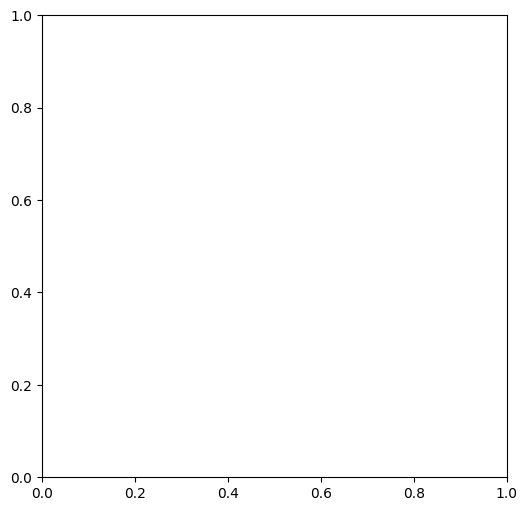

In [33]:
# Célula 28: Atualização do relatório HTML com calibração, custo e SHAP
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io, base64, datetime, json, sys
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, f1_score, brier_score_loss
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
import joblib

# Algumas dependências podem ser opcionais
try:
    import shap
except Exception:
    shap = None

# Utilidades
plt.rcParams.update({"figure.facecolor": "white"})

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()

base_dir = Path.cwd()  # Notebook está em DataSet
csv_path = base_dir / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
artef_dir = base_dir / "artefatos_modelo"
report_path = base_dir / "relatorio_churn.html"

# Carregar dados com mínimos ajustes compatíveis com os artefatos

def carregar_dados_telco(caminho_csv: Path):
    df = pd.read_csv(caminho_csv)
    # Limpeza mínima
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
        df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    # Alvo
    y = df['Churn'].astype(str).str.lower().str.strip().map({'yes': 1, 'no': 0}).astype(int)
    id_col = 'customerID' if 'customerID' in df.columns else None
    X = df.drop(columns=[c for c in ['Churn', 'customerID'] if c in df.columns])
    X_enc = pd.get_dummies(X, drop_first=True)
    return df, X_enc, y, id_col


def alinhar_colunas(X_enc: pd.DataFrame, colunas_artef):
    X2 = X_enc.copy()
    for c in colunas_artef:
        if c not in X2.columns:
            X2[c] = 0
    # remover extras não vistos pelo modelo
    X2 = X2[colunas_artef]
    return X2

# Carrega artefatos salvos
modelo = joblib.load(artef_dir / "modelo.joblib")
metadata = joblib.load(artef_dir / "metadata.joblib") if (artef_dir / "metadata.joblib").exists() else {}
colunas = joblib.load(artef_dir / "colunas_X_encoded.joblib")
scaler = joblib.load(artef_dir / "scaler.joblib") if (artef_dir / "scaler.joblib").exists() else None

use_scaled = metadata.get('use_scaled', False)
thr_meta = float(metadata.get('threshold', 0.5))

# Monta conjunto de teste reprodutível (aproximação do split original)
df_raw, X_enc, y, id_col = carregar_dados_telco(csv_path)
X_enc = alinhar_colunas(X_enc, colunas)
indices = np.arange(len(X_enc))
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_enc, y.values, indices, test_size=0.2, random_state=42, stratify=y.values
)

# Aplica scaler se necessário
X_te_infer = X_te
if use_scaled and scaler is not None:
    X_te_infer = scaler.transform(X_te)

# Probabilidades
if hasattr(modelo, 'predict_proba'):
    y_proba = modelo.predict_proba(X_te_infer)[:, 1]
elif hasattr(modelo, 'decision_function'):
    s = modelo.decision_function(X_te_infer)
    # normalização simples para [0,1] caso falte calibrador
    y_proba = (s - s.min()) / (s.max() - s.min() + 1e-8)
else:
    # fallback: usar previsões como probas binárias
    y_proba = modelo.predict(X_te_infer).astype(float)

# Métricas principais
roc_auc = roc_auc_score(y_te, y_proba)
prec, rec, thr_pr = precision_recall_curve(y_te, y_proba)
pr_auc = average_precision_score(y_te, y_proba)

# Threshold ótimo por F1
cand_thr = np.r_[0.0, thr_pr, 1.0]
best_f1, best_thr = -1.0, thr_meta
for t in cand_thr:
    y_hat = (y_proba >= t).astype(int)
    f1 = f1_score(y_te, y_hat)
    if f1 > best_f1:
        best_f1, best_thr = f1, float(t)

# Matriz de confusão no threshold F1-ótimo
cm = confusion_matrix(y_te, (y_proba >= best_thr).astype(int))

# Curva ROC
fpr, tpr, _ = roc_curve(y_te, y_proba)
fig_roc = plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
roc_img64 = fig_to_base64(fig_roc)

# Curva Precisão-Recall
fig_pr = plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precisão-Recall')
plt.legend()
pr_img64 = fig_to_base64(fig_pr)

# Curva de calibração e Brier
prob_true, prob_pred = calibration_curve(y_te, y_proba, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_te, y_proba)
fig_cal = plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, marker='o', label=f"Calibração (Brier={brier:.3f})")
plt.plot([0,1],[0,1],'--', color='gray', label='Perfeita')
plt.xlabel('Prob. prevista')
plt.ylabel('Frequência observada')
plt.title('Curva de Calibração')
plt.legend()
cal_img64 = fig_to_base64(fig_cal)

# Threshold ótimo por custo esperado (ex.: FN=10x FP)
C_FN, C_FP = 10.0, 1.0
cost_best, thr_cost = float('inf'), best_thr
for t in np.linspace(0, 1, 201):
    y_hat = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, y_hat).ravel()
    cost = C_FN * fn + C_FP * fp
    if cost < cost_best:
        cost_best, thr_cost = cost, float(t)

# SHAP (top-20 features por importância média |SHAP|), se aplicável
shap_img64 = None
try:
    is_tree_model = any(k in type(modelo).__name__.lower() for k in ['forest', 'xgb', 'xgboost', 'gradientboost', 'tree'])
    if shap is not None and is_tree_model:
        # Amostra para acelerar
        amostra = min(800, X_te.shape[0])
        X_sample = X_te.iloc[:amostra] if isinstance(X_te, pd.DataFrame) else pd.DataFrame(X_te[:amostra], columns=colunas)
        if use_scaled and scaler is not None:
            X_sample_infer = scaler.transform(X_sample)
        else:
            X_sample_infer = X_sample
        explainer = shap.TreeExplainer(modelo)
        shap_values = explainer.shap_values(X_sample_infer)
        # Se lista (classes), pegar classe positiva
        if isinstance(shap_values, list):
            shap_mat = np.abs(shap_values[1])
        else:
            shap_mat = np.abs(shap_values)
        mean_abs = shap_mat.mean(axis=0)
        order = np.argsort(mean_abs)[::-1][:20]
        labels = np.array(colunas)[order]
        vals = mean_abs[order]
        fig_shap = plt.figure(figsize=(6,6))
        y_pos = np.arange(len(labels))
        plt.barh(y_pos, vals[::-1])
        plt.yticks(y_pos, labels[::-1], fontsize=8)
        plt.xlabel('|SHAP| médio')
        plt.title('Top 20 atributos por importância (SHAP)')
        shap_img64 = fig_to_base64(fig_shap)
except Exception as e:
    shap_img64 = None

# Top 10 clientes com maior risco (conjunto de teste)
ids = df_raw[id_col].values if id_col else np.arange(len(df_raw))
ids_te = ids[idx_te]
rank_df = pd.DataFrame({
    'ID_Cliente': ids_te,
    'Prob_Churn': y_proba
}).sort_values('Prob_Churn', ascending=False).head(10)

# HTML simples com imagens embutidas (base64)
hoje = datetime.date.today().strftime('%d/%m/%Y')
cm_tn, cm_fp, cm_fn, cm_tp = cm.ravel()
html = f"""
<!DOCTYPE html>
<html lang='pt-br'>
<head>
<meta charset='utf-8'>
<title>Relatório de Churn</title>
<style>
 body {{ font-family: Arial, sans-serif; margin: 24px; }}
 h1, h2, h3 {{ color: #222; }}
 .kpi {{ display: flex; gap: 16px; flex-wrap: wrap; margin: 12px 0 24px; }}
 .card {{ border: 1px solid #ddd; padding: 12px 16px; border-radius: 8px; background:#fafafa; }}
 img {{ max-width: 560px; border:1px solid #eee; padding:4px; background:white; }}
 table {{ border-collapse: collapse; }}
 th, td {{ border:1px solid #ddd; padding:6px 8px; text-align:center; }}
 .grid {{ display:flex; gap:20px; flex-wrap:wrap; }}
</style>
</head>
<body>
  <h1>Relatório de Churn – {hoje}</h1>
  <div class='kpi'>
    <div class='card'><b>ROC AUC</b><div style='font-size:20px'>{roc_auc:.3f}</div></div>
    <div class='card'><b>PR AUC</b><div style='font-size:20px'>{pr_auc:.3f}</div></div>
    <div class='card'><b>F1 (thr ótimo)</b><div style='font-size:20px'>{best_f1:.3f}</div></div>
    <div class='card'><b>Threshold (F1)</b><div style='font-size:20px'>{best_thr:.3f}</div></div>
    <div class='card'><b>Threshold (custo)</b><div style='font-size:20px'>{thr_cost:.3f}</div></div>
    <div class='card'><b>Brier</b><div style='font-size:20px'>{brier:.3f}</div></div>
  </div>

  <h2>Matriz de Confusão (thr = {best_thr:.3f})</h2>
  <table>
    <tr><th></th><th>Prev. Neg</th><th>Prev. Pos</th></tr>
    <tr><th>Real Neg</th><td>{cm_tn}</td><td>{cm_fp}</td></tr>
    <tr><th>Real Pos</th><td>{cm_fn}</td><td>{cm_tp}</td></tr>
  </table>

  <h2>Curvas</h2>
  <div class='grid'>
    <div>
      <h3>ROC</h3>
      <img src='data:image/png;base64,{roc_img64}' />
    </div>
    <div>
      <h3>Precisão-Recall</h3>
      <img src='data:image/png;base64,{pr_img64}' />
    </div>
    <div>
      <h3>Calibração</h3>
      <img src='data:image/png;base64,{cal_img64}' />
    </div>
  </div>

  <h2>Top 10 clientes com maior probabilidade de churn (teste)</h2>
  {rank_df.to_html(index=False)}

  {f"<h2>Importâncias (SHAP)</h2><img src='data:image/png;base64," + shap_img64 + "' />" if shap_img64 else ""}

  <hr />
  <p style='color:#666'>Relatório gerado automaticamente a partir de artefatos do modelo e avaliação no conjunto de teste reconstruído (split reproduzível, random_state=42).</p>
</body>
</html>
"""

report_path.write_text(html, encoding='utf-8')
print(f"Relatório atualizado salvo em: {report_path}")

